# Lab 04 — Table Visualization (theo cấu trúc mới của course)

Cấu trúc: axes, color scales, amounts, distributions, many distributions, proportions, associations, trends, uncertainty.

## 0) Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

root = Path("..").resolve().parent
df = pd.read_csv(root / "data" / "gapminder.csv")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 1) Coordinate systems and axes
Mục tiêu: so sánh cùng dữ liệu trên hệ trục rectilinear và radial để thấy trade-off.

/var/folders/v6/3bggzf691gn6h26h5hxxgq400000gp/T/ipykernel_31217/1911760920.py:10: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(1,2,2, projection="polar")


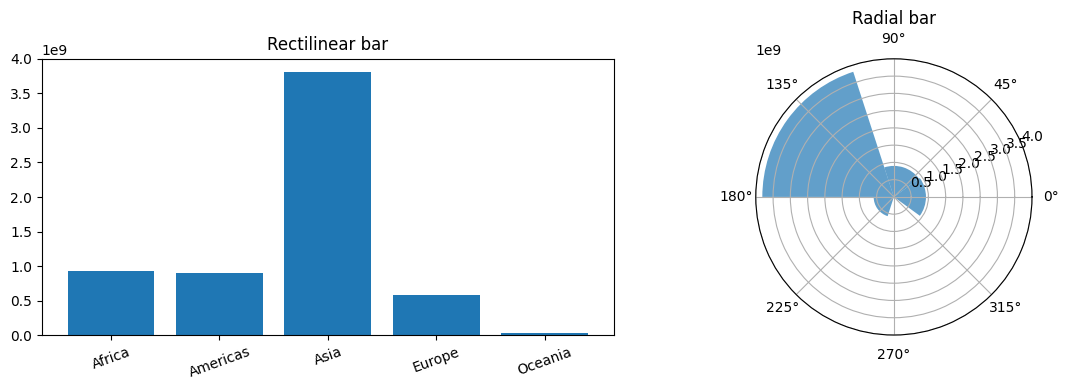

In [2]:
d = df[df["year"] == 2007].groupby("continent", as_index=False).agg(pop=("pop", "sum"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(d["continent"], d["pop"])
axes[0].set_title("Rectilinear bar")
axes[0].tick_params(axis="x", rotation=20)

angles = np.linspace(0, 2*np.pi, len(d), endpoint=False)
r = d["pop"].to_numpy()
ax = plt.subplot(1,2,2, projection="polar")
ax.bar(angles, r, width=2*np.pi/len(d), alpha=0.7)
ax.set_title("Radial bar")
plt.tight_layout()
plt.show()

## 2) Color scales
Mục tiêu: dùng sequential/diverging đúng ngữ cảnh.

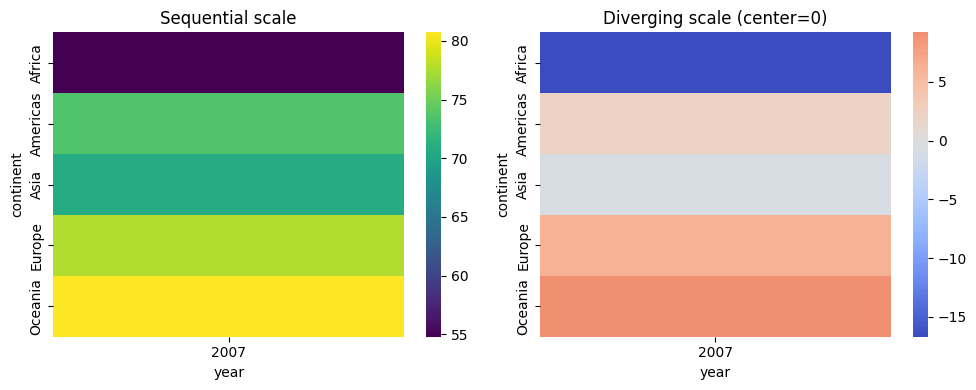

In [3]:
pivot = df[df["year"]==2007].pivot_table(index="continent", columns="year", values="lifeExp", aggfunc="mean")

fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(pivot, cmap="viridis", ax=axes[0], cbar=True)
axes[0].set_title("Sequential scale")

centered = pivot - pivot.mean().mean()
sns.heatmap(centered, cmap="coolwarm", center=0, ax=axes[1], cbar=True)
axes[1].set_title("Diverging scale (center=0)")
plt.tight_layout(); plt.show()

## 3) Visualizing amounts
Mục tiêu: biểu diễn lượng tuyệt đối bằng bar/dot.

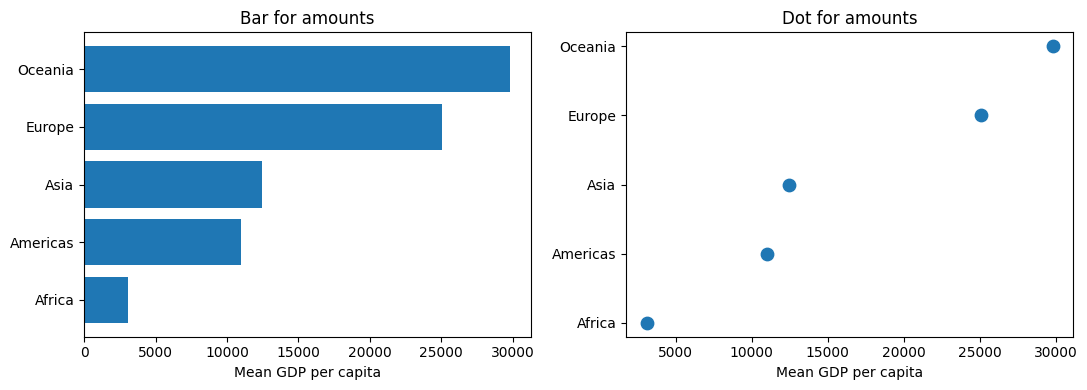

In [4]:
amt = df[df["year"]==2007].groupby("continent", as_index=False).agg(gdp=("gdpPercap","mean"))
amt = amt.sort_values("gdp")

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].barh(amt["continent"], amt["gdp"])
axes[0].set_title("Bar for amounts")
axes[0].set_xlabel("Mean GDP per capita")

axes[1].scatter(amt["gdp"], amt["continent"], s=80)
axes[1].set_title("Dot for amounts")
axes[1].set_xlabel("Mean GDP per capita")
plt.tight_layout(); plt.show()

## 4) Visualizing distributions
Mục tiêu: histogram + boxplot cho phân phối.

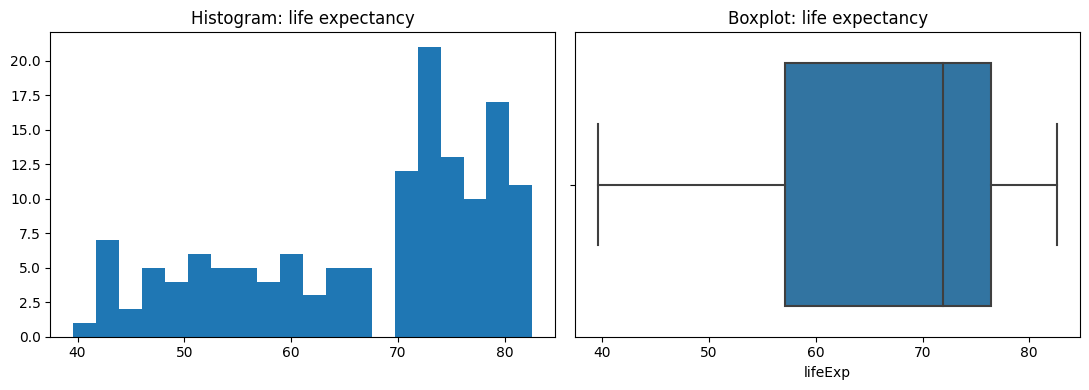

In [5]:
d2007 = df[df["year"]==2007].copy()
fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].hist(d2007["lifeExp"], bins=20)
axes[0].set_title("Histogram: life expectancy")

sns.boxplot(x=d2007["lifeExp"], ax=axes[1])
axes[1].set_title("Boxplot: life expectancy")
plt.tight_layout(); plt.show()

## 5) Visualizing many distributions at once
Mục tiêu: so sánh nhiều phân phối theo nhóm.

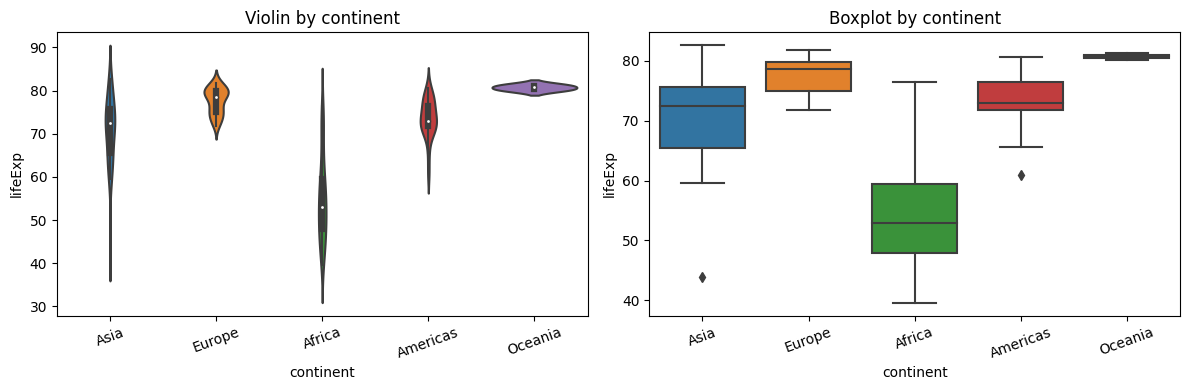

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.violinplot(data=d2007, x="continent", y="lifeExp", ax=axes[0])
axes[0].set_title("Violin by continent")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=d2007, x="continent", y="lifeExp", ax=axes[1])
axes[1].set_title("Boxplot by continent")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 6) Visualizing proportions
Mục tiêu: pie vs normalized stacked bar.

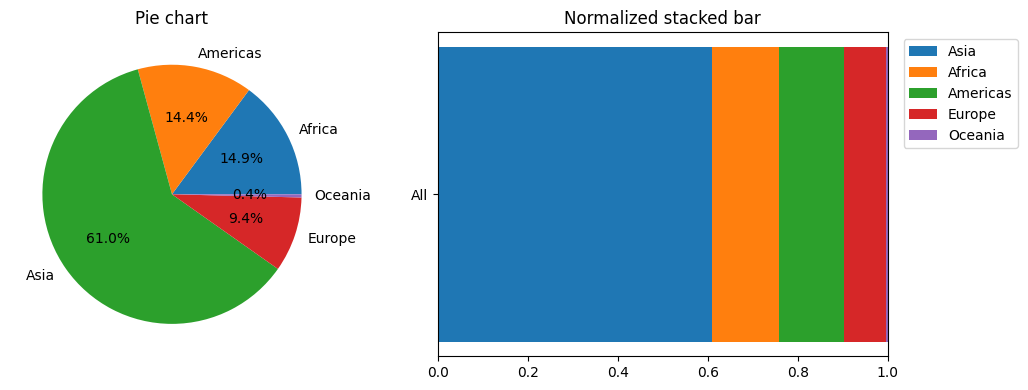

In [7]:
prop = d2007.groupby("continent", as_index=False).agg(pop=("pop","sum"))
prop["pct"] = prop["pop"]/prop["pop"].sum()

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].pie(prop["pct"], labels=prop["continent"], autopct="%.1f%%")
axes[0].set_title("Pie chart")

cum = 0
for _, row in prop.sort_values("pct", ascending=False).iterrows():
    axes[1].barh(["All"], [row["pct"]], left=[cum], label=row["continent"])
    cum += row["pct"]
axes[1].set_xlim(0,1)
axes[1].set_title("Normalized stacked bar")
axes[1].legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()

## 7) Visualizing associations
Mục tiêu: scatter + correlation.

Correlation:
            gdpPercap  lifeExp    pop
gdpPercap      1.000    0.679 -0.056
lifeExp        0.679    1.000  0.048
pop           -0.056    0.048  1.000


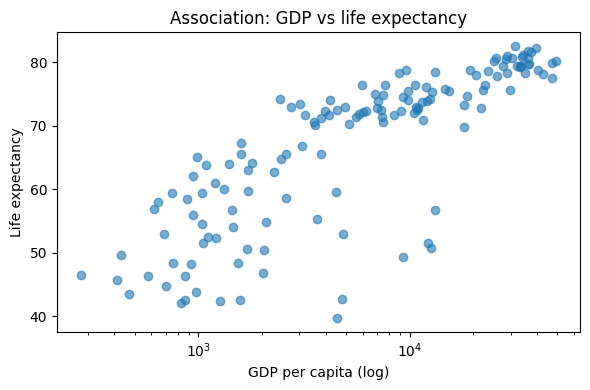

In [8]:
assoc = d2007[["gdpPercap", "lifeExp", "pop"]].copy()
print("Correlation:\n", assoc.corr(numeric_only=True).round(3))

plt.figure(figsize=(6,4))
plt.scatter(assoc["gdpPercap"], assoc["lifeExp"], alpha=0.6)
plt.xscale("log")
plt.xlabel("GDP per capita (log)")
plt.ylabel("Life expectancy")
plt.title("Association: GDP vs life expectancy")
plt.tight_layout(); plt.show()

## 8) Visualizing trends
Mục tiêu: line chart theo thời gian.

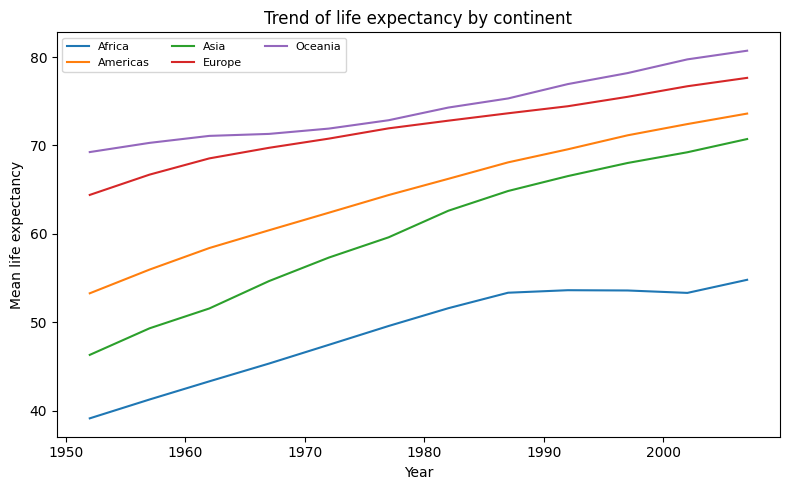

In [9]:
trend = df.groupby(["year","continent"], as_index=False).agg(lifeExp=("lifeExp","mean"))
plt.figure(figsize=(8,5))
for c, g in trend.groupby("continent"):
    plt.plot(g["year"], g["lifeExp"], label=c)
plt.title("Trend of life expectancy by continent")
plt.xlabel("Year"); plt.ylabel("Mean life expectancy")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

## 9) Visualizing uncertainty
Mục tiêu: hiển thị CI cho trend.

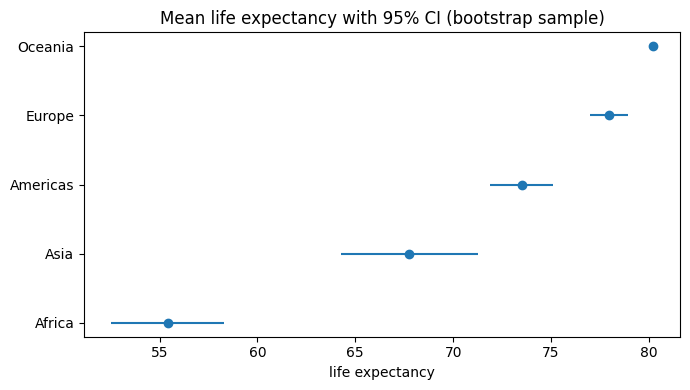

,continent,mean,ci95
0,Africa,55.419596,2.881695
2,Asia,67.765478,3.486758
1,Americas,73.498629,1.591938
3,Europe,77.956486,0.952134
4,Oceania,80.204000,0.000000


In [10]:
sample = d2007.sample(frac=1.0, replace=True, random_state=42)
summary = sample.groupby("continent")["lifeExp"].agg(["mean","std","count"]).reset_index()
summary["se"] = summary["std"]/np.sqrt(summary["count"])
summary["ci95"] = 1.96*summary["se"]
summary = summary.sort_values("mean")

plt.figure(figsize=(7,4))
plt.errorbar(summary["mean"], summary["continent"], xerr=summary["ci95"], fmt="o")
plt.title("Mean life expectancy with 95% CI (bootstrap sample)")
plt.xlabel("life expectancy")
plt.tight_layout(); plt.show()
summary[["continent","mean","ci95"]]

## Reflection
- Nêu rõ khi nào dùng từng nhóm biểu đồ ở trên.
- Chỉ ra 2 lỗi diễn giải dễ gặp (pie với nhiều nhóm, line cho categorical, v.v.).
- Kết luận: với data bảng, chọn chart theo task (amount/distribution/proportion/association/trend/uncertainty), không chọn theo thói quen.